In [2]:
import json
import pandas as pd
import numpy as np

In [3]:
with open("../data/raw_data/dly-0-20000-0-11519-202605.json") as f:
    raw_data = json.load(f)

In [4]:
raw_data.keys()
print(raw_data)

{'zaznamID': '49ebf720-2fc8-0c9b-7aa7-b7153ef10202', 'datovyZdrojID': 'meteorologie', 'datovyTokID': 'Open.Data.1D', 'datumVytvoreni': '2026-05-06T12:40:05.309Z', 'verzeDat': '1.0', 'data': {'type': 'DataCollection', 'data': {'header': 'STATION,ELEMENT,VTYPE,DT,VAL,FLAG,QUALITY', 'values': [['0-20000-0-11519', 'API30', '06:00', '2026-05-01T06:00:00Z', 3.6, '', 0.0], ['0-20000-0-11519', 'API30', '06:00', '2026-05-02T06:00:00Z', 3.4, '', 0.0], ['0-20000-0-11519', 'API30', '06:00', '2026-05-03T06:00:00Z', 3.1, '', 0.0], ['0-20000-0-11519', 'API30', '06:00', '2026-05-04T06:00:00Z', 2.9, '', 0.0], ['0-20000-0-11519', 'API30', '06:00', '2026-05-05T06:00:00Z', 3.8, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-01T00:00:00Z', 1243.0, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-02T00:00:00Z', 1713.0, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-03T00:00:00Z', 1803.0, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-04T00:00:00Z', 2316.0, '', 0.0],

In [8]:
raw_data["data"].keys()

dict_keys(['type', 'data'])

In [11]:
raw_data["data"]["data"].keys()

dict_keys(['header', 'values'])

In [12]:
raw_data["data"]["type"].keys()

AttributeError: 'str' object has no attribute 'keys'

In [14]:
raw_data["data"]["data"]["header"].keys()

AttributeError: 'str' object has no attribute 'keys'

In [17]:
raw_data["data"]["data"]["values"].keys()

AttributeError: 'list' object has no attribute 'values'

In [19]:
print(raw_data["data"]["type"])
print(raw_data["data"]["data"]["header"])

DataCollection
STATION,ELEMENT,VTYPE,DT,VAL,FLAG,QUALITY


In [21]:
print(len(raw_data["data"]["data"]["values"]))

170


In [23]:
print(raw_data["data"]["data"]["values"][5:10])

[['0-20000-0-11519', 'Casmax', '00:00', '2026-05-01T00:00:00Z', 1243.0, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-02T00:00:00Z', 1713.0, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-03T00:00:00Z', 1803.0, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-04T00:00:00Z', 2316.0, '', 0.0], ['0-20000-0-11519', 'Casmax', '00:00', '2026-05-05T00:00:00Z', 1731.0, '', 0.0]]


In [24]:
print(set([item[1] for item in raw_data["data"]["data"]["values"]]))


{'Dmax', 'SRA', 'D10', 'H', 'P', 'T', 'TMA', 'API30', 'Casmax', 'F', 'SSV', 'TMInoc', 'RGLB_D', 'Fmax', 'TMI', 'E', 'VY'}


In [25]:
print(set([item[2] for item in raw_data["data"]["data"]["values"]]))

{'06:00', '20:00', 'SUM', '13:00', '00:00', 'AVG'}


In [49]:
column_names = str.split(raw_data["data"]["data"]["header"],sep= ",")

df = pd.DataFrame(data = raw_data["data"]["data"]["values"] , columns = column_names)
column_names

['STATION', 'ELEMENT', 'VTYPE', 'DT', 'VAL', 'FLAG', 'QUALITY']

In [50]:
df

,STATION,ELEMENT,VTYPE,DT,VAL,FLAG,QUALITY
0,0-20000-0-11519,API30,06:00,2026-05-01T06:00:00Z,3.6,,0.0
1,0-20000-0-11519,API30,06:00,2026-05-02T06:00:00Z,3.4,,0.0
2,0-20000-0-11519,API30,06:00,2026-05-03T06:00:00Z,3.1,,0.0
3,0-20000-0-11519,API30,06:00,2026-05-04T06:00:00Z,2.9,,0.0
4,0-20000-0-11519,API30,06:00,2026-05-05T06:00:00Z,3.8,,0.0
...,...,...,...,...,...,...,...
165,0-20000-0-11519,VY,06:00,2026-05-01T06:00:00Z,,,4.0
166,0-20000-0-11519,VY,06:00,2026-05-02T06:00:00Z,,,4.0
167,0-20000-0-11519,VY,06:00,2026-05-03T06:00:00Z,,,4.0
168,0-20000-0-11519,VY,06:00,2026-05-04T06:00:00Z,,,4.0


In [38]:

df.to_csv("../data/post_process_data/out_csv.csv")

In [51]:
df.drop(columns=["FLAG","QUALITY"])

,STATION,ELEMENT,VTYPE,DT,VAL
0,0-20000-0-11519,API30,06:00,2026-05-01T06:00:00Z,3.6
1,0-20000-0-11519,API30,06:00,2026-05-02T06:00:00Z,3.4
2,0-20000-0-11519,API30,06:00,2026-05-03T06:00:00Z,3.1
3,0-20000-0-11519,API30,06:00,2026-05-04T06:00:00Z,2.9
4,0-20000-0-11519,API30,06:00,2026-05-05T06:00:00Z,3.8
...,...,...,...,...,...
165,0-20000-0-11519,VY,06:00,2026-05-01T06:00:00Z,
166,0-20000-0-11519,VY,06:00,2026-05-02T06:00:00Z,
167,0-20000-0-11519,VY,06:00,2026-05-03T06:00:00Z,
168,0-20000-0-11519,VY,06:00,2026-05-04T06:00:00Z,


In [52]:
df["ELEMENT_VTYPE"] = df["ELEMENT"] + "_" + df["VTYPE"]

df.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")


ELEMENT_VTYPE,API30_06:00,Casmax_00:00,D10_06:00,D10_13:00,D10_20:00,Dmax_00:00,E_06:00,E_13:00,E_20:00,E_AVG,...,SRA_06:00,SSV_00:00,TMA_20:00,TMI_20:00,TMInoc_06:00,T_06:00,T_13:00,T_20:00,T_AVG,VY_06:00
DT,,,,,,,,,,,,,,,,,,,,,
2026-05-01T00:00:00Z,NaN,1243.0,NaN,NaN,NaN,355.0,NaN,NaN,NaN,6.7,...,NaN,13.9,NaN,NaN,NaN,NaN,NaN,NaN,14.6,NaN
2026-05-01T06:00:00Z,3.6,NaN,23.0,NaN,NaN,NaN,5.9,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,3.5,6.4,NaN,NaN,NaN,
2026-05-01T13:00:00Z,NaN,NaN,NaN,33.0,NaN,NaN,NaN,6.4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.7,NaN,NaN,NaN
2026-05-01T20:00:00Z,NaN,NaN,NaN,NaN,26.0,NaN,NaN,NaN,7.9,NaN,...,NaN,NaN,22.1,3.5,NaN,NaN,NaN,16.1,NaN,NaN
2026-05-02T00:00:00Z,NaN,1713.0,NaN,NaN,NaN,101.0,NaN,NaN,NaN,6.5,...,NaN,13.8,NaN,NaN,NaN,NaN,NaN,NaN,17.8,NaN
2026-05-02T06:00:00Z,3.4,NaN,17.0,NaN,NaN,NaN,7.5,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,6.0,9.6,NaN,NaN,NaN,
2026-05-02T13:00:00Z,NaN,NaN,NaN,11.0,NaN,NaN,NaN,5.4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,NaN
2026-05-02T20:00:00Z,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN,6.7,NaN,...,NaN,NaN,26.0,6.0,NaN,NaN,NaN,18.8,NaN,NaN
2026-05-03T00:00:00Z,NaN,1803.0,NaN,NaN,NaN,129.0,NaN,NaN,NaN,7.2,...,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,20.8,NaN


In [74]:
daily_table = df[df["DT"].str.contains("T00:00")]


In [75]:
daily_table.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")

ELEMENT_VTYPE,Casmax_00:00,Dmax_00:00,E_AVG,F_AVG,Fmax_00:00,H_AVG,P_AVG,RGLB_D_SUM,SSV_00:00,T_AVG
DT,,,,,,,,,,
2026-05-01T00:00:00Z,1243.0,355.0,6.7,1.5,6.2,44.0,997.4,25718.0,13.9,14.6
2026-05-02T00:00:00Z,1713.0,101.0,6.5,1.5,6.1,37.0,991.7,26368.0,13.8,17.8
2026-05-03T00:00:00Z,1803.0,129.0,7.2,2.5,8.0,32.0,984.8,25341.0,13.0,20.8
2026-05-04T00:00:00Z,2316.0,204.0,9.3,1.4,10.6,43.0,983.0,18561.0,7.7,19.7
2026-05-05T00:00:00Z,1731.0,125.0,12.0,2.6,14.2,56.0,976.7,21793.0,8.9,19.4


In [65]:
xy = df[df["DT"].str.contains("T06:00")]
xy.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")

ELEMENT_VTYPE,API30_06:00,D10_06:00,E_06:00,F_06:00,H_06:00,P_06:00,SRA_06:00,TMInoc_06:00,T_06:00,VY_06:00
DT,,,,,,,,,,
2026-05-01T06:00:00Z,3.6,23.0,5.9,1.2,61.0,999.4,0.0,3.5,6.4,
2026-05-02T06:00:00Z,3.4,17.0,7.5,1.7,63.0,995.4,0.0,6.0,9.6,
2026-05-03T06:00:00Z,3.1,11.0,7.4,0.9,45.0,987.5,0.0,9.4,14.4,
2026-05-04T06:00:00Z,2.9,29.0,9.1,1.5,58.0,984.3,1.3,12.1,13.7,
2026-05-05T06:00:00Z,3.8,25.0,13.5,1.5,80.0,979.3,4.1,13.1,14.8,


In [61]:
x = df[df["DT"].str.contains("T13:00")]
x.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")

ELEMENT_VTYPE,D10_13:00,E_13:00,F_13:00,H_13:00,P_13:00,T_13:00
DT,,,,,,
2026-05-01T13:00:00Z,33.0,6.4,2.1,28.0,997.2,19.7
2026-05-02T13:00:00Z,11.0,5.4,1.9,18.0,991.3,24.0
2026-05-03T13:00:00Z,11.0,6.6,3.9,20.0,984.2,25.6
2026-05-04T13:00:00Z,3.0,8.8,1.3,30.0,983.0,23.8
2026-05-05T13:00:00Z,9.0,10.7,2.3,33.0,976.1,25.4


In [62]:
x = df[df["DT"].str.contains("T20:00")]
x.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")

ELEMENT_VTYPE,D10_20:00,E_20:00,F_20:00,H_20:00,P_20:00,TMA_20:00,TMI_20:00,T_20:00
DT,,,,,,,,
2026-05-01T20:00:00Z,26.0,7.9,1.1,43.0,995.7,22.1,3.5,16.1
2026-05-02T20:00:00Z,12.0,6.7,0.8,31.0,988.3,26.0,6.0,18.8
2026-05-03T20:00:00Z,17.0,7.7,2.7,30.0,982.8,27.7,9.4,21.6
2026-05-04T20:00:00Z,9.0,10.0,1.5,41.0,981.8,25.1,12.1,20.6
2026-05-05T20:00:00Z,26.0,11.8,4.0,55.0,974.8,25.8,13.1,18.6


AttributeError: 'Series' object has no attribute 'pivot'

In [108]:
daily_table = df[df["DT"].str.contains("T00:00")]
daily_table = daily_table.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")
daily_table.index = pd.to_datetime(daily_table.index).date

In [109]:
daily_table

ELEMENT_VTYPE,Casmax_00:00,Dmax_00:00,E_AVG,F_AVG,Fmax_00:00,H_AVG,P_AVG,RGLB_D_SUM,SSV_00:00,T_AVG
2026-05-01,1243.0,355.0,6.7,1.5,6.2,44.0,997.4,25718.0,13.9,14.6
2026-05-02,1713.0,101.0,6.5,1.5,6.1,37.0,991.7,26368.0,13.8,17.8
2026-05-03,1803.0,129.0,7.2,2.5,8.0,32.0,984.8,25341.0,13.0,20.8
2026-05-04,2316.0,204.0,9.3,1.4,10.6,43.0,983.0,18561.0,7.7,19.7
2026-05-05,1731.0,125.0,12.0,2.6,14.2,56.0,976.7,21793.0,8.9,19.4


In [ ]:
six_am_table = df[df["DT"].str.contains("T06:00")]
six_am_table = six_am_table.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")
six_am_table.index = pd.to_datetime(six_am_table.index).date
six_am_table.drop(columns="VY_06:00")

In [115]:
night_table = df[df["DT"].str.contains("T20:00")]
night_table = night_table.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")
night_table.index = pd.to_datetime(night_table.index).date
night_table

ELEMENT_VTYPE,D10_20:00,E_20:00,F_20:00,H_20:00,P_20:00,TMA_20:00,TMI_20:00,T_20:00
2026-05-01,26.0,7.9,1.1,43.0,995.7,22.1,3.5,16.1
2026-05-02,12.0,6.7,0.8,31.0,988.3,26.0,6.0,18.8
2026-05-03,17.0,7.7,2.7,30.0,982.8,27.7,9.4,21.6
2026-05-04,9.0,10.0,1.5,41.0,981.8,25.1,12.1,20.6
2026-05-05,26.0,11.8,4.0,55.0,974.8,25.8,13.1,18.6


In [117]:
daily_table = (
    daily_table
    .assign(API_30_6_00 = lambda x : six_am_table["API30_06:00"])
    .assign(TMInoc_06_00 = lambda x : six_am_table["TMInoc_06:00"] )
    .assign(SRA_06_00 = lambda x : six_am_table["SRA_06:00"])
    .assign(TMA_8_00 = lambda x : night_table["TMA_20:00"])
    .assign(TMI_20_00 = lambda x : night_table["TMI_20:00"])
)

In [118]:
daily_table

ELEMENT_VTYPE,Casmax_00:00,Dmax_00:00,E_AVG,F_AVG,Fmax_00:00,H_AVG,P_AVG,RGLB_D_SUM,SSV_00:00,T_AVG,API_30_6_00,TMInoc_06_00,SRA_06_00,TMA_8_00,TMI_20_00
2026-05-01,1243.0,355.0,6.7,1.5,6.2,44.0,997.4,25718.0,13.9,14.6,3.6,3.5,0.0,22.1,3.5
2026-05-02,1713.0,101.0,6.5,1.5,6.1,37.0,991.7,26368.0,13.8,17.8,3.4,6.0,0.0,26.0,6.0
2026-05-03,1803.0,129.0,7.2,2.5,8.0,32.0,984.8,25341.0,13.0,20.8,3.1,9.4,0.0,27.7,9.4
2026-05-04,2316.0,204.0,9.3,1.4,10.6,43.0,983.0,18561.0,7.7,19.7,2.9,12.1,1.3,25.1,12.1
2026-05-05,1731.0,125.0,12.0,2.6,14.2,56.0,976.7,21793.0,8.9,19.4,3.8,13.1,4.1,25.8,13.1


### second table


In [151]:
night_t = df[df["DT"].str.contains("T20:00")]
midday_t = df[df["DT"].str.contains("T13:00")]
mornig_t = df[df["DT"].str.contains("T06:00")]
night_t = night_t.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")
midday_t = midday_t.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")
mornig_t = mornig_t.pivot(index="DT",columns= ["ELEMENT_VTYPE"],values="VAL")

mornig_t

ELEMENT_VTYPE,API30_06:00,D10_06:00,E_06:00,F_06:00,H_06:00,P_06:00,SRA_06:00,TMInoc_06:00,T_06:00,VY_06:00
DT,,,,,,,,,,
2026-05-01T06:00:00Z,3.6,23.0,5.9,1.2,61.0,999.4,0.0,3.5,6.4,
2026-05-02T06:00:00Z,3.4,17.0,7.5,1.7,63.0,995.4,0.0,6.0,9.6,
2026-05-03T06:00:00Z,3.1,11.0,7.4,0.9,45.0,987.5,0.0,9.4,14.4,
2026-05-04T06:00:00Z,2.9,29.0,9.1,1.5,58.0,984.3,1.3,12.1,13.7,
2026-05-05T06:00:00Z,3.8,25.0,13.5,1.5,80.0,979.3,4.1,13.1,14.8,


In [154]:
night_t = night_t[["D10_20:00" ,"E_20:00","F_20:00","H_20:00", "P_20:00","T_20:00"]]
night_t.columns = ["D10", "E", "F", "H", "P", "T"]


In [152]:
mornig_t = mornig_t[["D10_06:00" ,"E_06:00","F_06:00","H_06:00", "P_06:00","T_06:00"]]
mornig_t.columns = ["D10", "E", "F", "H", "P", "T"]

In [153]:
mornig_t

,D10,E,F,H,P,T
DT,,,,,,
2026-05-01T06:00:00Z,23.0,5.9,1.2,61.0,999.4,6.4
2026-05-02T06:00:00Z,17.0,7.5,1.7,63.0,995.4,9.6
2026-05-03T06:00:00Z,11.0,7.4,0.9,45.0,987.5,14.4
2026-05-04T06:00:00Z,29.0,9.1,1.5,58.0,984.3,13.7
2026-05-05T06:00:00Z,25.0,13.5,1.5,80.0,979.3,14.8


In [155]:
night_t

,D10,E,F,H,P,T
DT,,,,,,
2026-05-01T20:00:00Z,26.0,7.9,1.1,43.0,995.7,16.1
2026-05-02T20:00:00Z,12.0,6.7,0.8,31.0,988.3,18.8
2026-05-03T20:00:00Z,17.0,7.7,2.7,30.0,982.8,21.6
2026-05-04T20:00:00Z,9.0,10.0,1.5,41.0,981.8,20.6
2026-05-05T20:00:00Z,26.0,11.8,4.0,55.0,974.8,18.6


In [156]:
midday_t.columns = ["D10", "E", "F", "H", "P", "T"]

In [157]:
midday_t

,D10,E,F,H,P,T
DT,,,,,,
2026-05-01T13:00:00Z,33.0,6.4,2.1,28.0,997.2,19.7
2026-05-02T13:00:00Z,11.0,5.4,1.9,18.0,991.3,24.0
2026-05-03T13:00:00Z,11.0,6.6,3.9,20.0,984.2,25.6
2026-05-04T13:00:00Z,3.0,8.8,1.3,30.0,983.0,23.8
2026-05-05T13:00:00Z,9.0,10.7,2.3,33.0,976.1,25.4


In [161]:
series_table = pd.concat([night_t, midday_t, mornig_t])

In [163]:
series_table

,D10,E,F,H,P,T
DT,,,,,,
2026-05-01T20:00:00Z,26.0,7.9,1.1,43.0,995.7,16.1
2026-05-02T20:00:00Z,12.0,6.7,0.8,31.0,988.3,18.8
2026-05-03T20:00:00Z,17.0,7.7,2.7,30.0,982.8,21.6
2026-05-04T20:00:00Z,9.0,10.0,1.5,41.0,981.8,20.6
2026-05-05T20:00:00Z,26.0,11.8,4.0,55.0,974.8,18.6
2026-05-01T13:00:00Z,33.0,6.4,2.1,28.0,997.2,19.7
2026-05-02T13:00:00Z,11.0,5.4,1.9,18.0,991.3,24.0
2026-05-03T13:00:00Z,11.0,6.6,3.9,20.0,984.2,25.6
2026-05-04T13:00:00Z,3.0,8.8,1.3,30.0,983.0,23.8


In [164]:
series_table = series_table.sort_index()

In [167]:
print(series_table)

                       D10     E    F     H      P     T
DT                                                      
2026-05-01T06:00:00Z  23.0   5.9  1.2  61.0  999.4   6.4
2026-05-01T13:00:00Z  33.0   6.4  2.1  28.0  997.2  19.7
2026-05-01T20:00:00Z  26.0   7.9  1.1  43.0  995.7  16.1
2026-05-02T06:00:00Z  17.0   7.5  1.7  63.0  995.4   9.6
2026-05-02T13:00:00Z  11.0   5.4  1.9  18.0  991.3  24.0
2026-05-02T20:00:00Z  12.0   6.7  0.8  31.0  988.3  18.8
2026-05-03T06:00:00Z  11.0   7.4  0.9  45.0  987.5  14.4
2026-05-03T13:00:00Z  11.0   6.6  3.9  20.0  984.2  25.6
2026-05-03T20:00:00Z  17.0   7.7  2.7  30.0  982.8  21.6
2026-05-04T06:00:00Z  29.0   9.1  1.5  58.0  984.3  13.7
2026-05-04T13:00:00Z   3.0   8.8  1.3  30.0  983.0  23.8
2026-05-04T20:00:00Z   9.0  10.0  1.5  41.0  981.8  20.6
2026-05-05T06:00:00Z  25.0  13.5  1.5  80.0  979.3  14.8
2026-05-05T13:00:00Z   9.0  10.7  2.3  33.0  976.1  25.4
2026-05-05T20:00:00Z  26.0  11.8  4.0  55.0  974.8  18.6


# hourly data

In [172]:
with open("../data/raw_data/1h-0-20000-0-11519-20260509.json") as f:
    raw_1h = json.load(f)
raw_1h["data"]["data"]["values"]

[['0-20000-0-11519', 'C-C1Av', '2026-05-09T00:00:00Z', 1879.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T01:00:00Z', 1685.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T02:00:00Z', 1837.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T03:00:00Z', 1808.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T04:00:00Z', 1795.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T05:00:00Z', 1750.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T06:00:00Z', 1235.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T07:00:00Z', 956.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T08:00:00Z', 1108.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T09:00:00Z', 1244.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T10:00:00Z', 1380.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T11:00:00Z', 1559.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T12:00:00Z', 1533.0, '', 0.0],
 ['0-20000-0-11519', 'C-C1Av', '2026-05-09T13:00:00Z

In [168]:
raw_1h["data"].keys()
raw_1h["data"]["data"].keys()
print(raw_1h["data"]["data"]["header"])
print(len(raw_1h["data"]["data"]["values"]))
print(set(item[1] for item in raw_1h["data"]["data"]["values"]))
column_names = str.split(raw_1h["data"]["data"]["header"],sep= ",")
df_1 = pd.DataFrame(data = raw_1h["data"]["data"]["values"] , columns = column_names)

STATION,ELEMENT,DT,VAL,FLAG,QUALITY
954
{'E', 'C-C2Mx', 'C-C2Co', 'C-H2Mx', 'C-H2Co', 'C-I2Co', 'C-C3Av', 'C-C1Mx', 'RGLB1H', 'C-H3Co', 'C-H3Av', 'C-I2Md', 'C-C3Mn', 'C-I1Su', 'C-H2Mn', 'C-MLAv', 'C-C2Mn', 'C-H1Co', 'C-C1Co', 'C-C1Av', 'C-C2Av', 'C-H1Av', 'SRA1H', 'C-I3Su', 'C-C1Mn', 'C-I3Co', 'C-C3Mx', 'C-H2Av', 'SSV1H', 'C-H1Mx', 'C-I1Co', 'C-C3Co', 'C-I2Su', 'C-H3Mn', 'C-H1Mn', 'C-H3Mx', 'P_hm', 'C-I3Md', 'C-MLI', 'C-I1Md'}


In [169]:
column_names = str.split(raw_1h["data"]["data"]["header"],sep= ",")
df_1 = pd.DataFrame(data = raw_1h["data"]["data"]["values"] , columns = column_names)

df_1 = df_1.pivot(index="DT",columns= ["ELEMENT"],values="VAL")
df_1.index = pd.to_datetime(df_1.index)
df_1.index.name = None
df_1 = df_1.reset_index().rename(columns={"index": "DATE"})
df_1.columns.name = None
df_1["DATE"] = df_1["DATE"].dt.tz_localize(None)


In [170]:
df_1

,DATE,C-C1Av,C-C1Co,C-C1Mn,C-C1Mx,C-C2Av,C-C2Co,C-C2Mn,C-C2Mx,C-C3Av,...,C-I3Co,C-I3Md,C-I3Su,C-MLAv,C-MLI,E,P_hm,RGLB1H,SRA1H,SSV1H
0,2026-05-09 00:00:00,1879.0,13.0,1870.0,1900.0,,0.0,,,,...,111.0,2.0,209.0,470.0,2.0,9.5,1020.3,2.7,0.0,NaN
1,2026-05-09 01:00:00,1685.0,151.0,780.0,1910.0,1860.0,4.0,1860.0,1860.0,,...,188.0,2.0,367.0,82.0,3.0,9.5,1020.3,2.4,0.0,NaN
2,2026-05-09 02:00:00,1837.0,176.0,1800.0,1880.0,,0.0,,,,...,225.0,2.0,422.0,470.0,2.0,9.6,1020.5,2.4,0.0,NaN
3,2026-05-09 03:00:00,1808.0,36.0,1780.0,1820.0,,0.0,,,,...,225.0,2.0,455.0,470.0,2.0,9.5,1020.3,3.0,0.0,0.0
4,2026-05-09 04:00:00,1795.0,135.0,1730.0,1830.0,,0.0,,,,...,215.0,2.0,439.0,460.0,2.0,9.6,1020.2,13.7,0.0,0.0
5,2026-05-09 05:00:00,1750.0,195.0,1580.0,1860.0,1844.0,10.0,1820.0,1870.0,,...,164.0,2.0,307.0,400.0,3.0,9.8,1020.5,87.2,0.0,3.0
6,2026-05-09 06:00:00,1235.0,81.0,400.0,1810.0,1803.0,7.0,1760.0,1820.0,,...,106.0,2.0,176.0,370.0,2.0,9.8,1020.6,182.6,0.0,2.0
7,2026-05-09 07:00:00,956.0,134.0,530.0,1600.0,1517.0,10.0,930.0,1600.0,1590.0,...,10.0,2.0,18.0,630.0,2.0,9.7,1020.7,402.1,0.0,8.0
8,2026-05-09 08:00:00,1108.0,196.0,710.0,1630.0,1422.0,30.0,1010.0,1630.0,,...,23.0,1.0,23.0,680.0,2.0,9.8,1020.4,511.5,0.0,8.0
9,2026-05-09 09:00:00,1244.0,225.0,950.0,1490.0,1350.0,2.0,1310.0,1390.0,,...,0.0,,,1110.0,1.0,9.2,1020.3,228.0,0.0,0.0


In [176]:
df = pd.read_csv("../data/post_process_data/dly-0-20000-0-11518-T.csv",encoding="utf-8-sig")
print(df.head())

           STATION ELEMENT TIMEFUNC                 DT  VALUE  FLAG  QUALITY  \
0  0-20000-0-11518       T      AVG  1946-01-01T00:00Z   -6.3   NaN      0.0   
1  0-20000-0-11518       T      AVG  1946-01-02T00:00Z   -6.3   NaN      0.0   
2  0-20000-0-11518       T      AVG  1946-01-03T00:00Z   -5.3   NaN      0.0   
3  0-20000-0-11518       T      AVG  1946-01-04T00:00Z   -5.8   NaN      0.0   
4  0-20000-0-11518       T      AVG  1946-01-05T00:00Z   -4.3   NaN      0.0   

   Unnamed: 7  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  


In [180]:
df["VALUE"].sort_values(ascending=False)

62645    36.3
82778    36.1
62643    35.6
72511    35.4
87521    35.3
         ... 
32911   -25.2
3691    -25.2
32903   -25.7
91351   -26.4
32912   -26.6
Name: VALUE, Length: 116880, dtype: float64

In [184]:
df.loc[df["VALUE"].idxmax()]
print(df["DT"].min(), df["DT"].max())

1946-01-01T00:00Z 2025-12-31T20:00Z


In [187]:
print("Top 5 hottest:")
print(df.nlargest(20, "VALUE")[["DT", "VALUE", "TIMEFUNC"]])

print("\nTop 15 coldest:")
print(df.nsmallest(20, "VALUE")[["DT", "VALUE", "TIMEFUNC"]])

Top 5 hottest:
                      DT  VALUE TIMEFUNC
62645  1957-07-07T13:00Z   36.3    13:00
82778  2012-08-20T13:00Z   36.1    13:00
62643  1957-07-05T13:00Z   35.6    13:00
72511  1984-07-11T13:00Z   35.4    13:00
87521  2025-08-15T13:00Z   35.3    13:00
72161  1983-07-27T13:00Z   35.2    13:00
77656  1998-08-12T13:00Z   35.2    13:00
83861  2015-08-08T13:00Z   35.0    13:00
85283  2019-06-30T13:00Z   35.0    13:00
76183  1994-07-31T13:00Z   34.9    13:00
76184  1994-08-01T13:00Z   34.8    13:00
85279  2019-06-26T13:00Z   34.8    13:00
85284  2019-07-01T13:00Z   34.8    13:00
83126  2013-08-03T13:00Z   34.7    13:00
76182  1994-07-30T13:00Z   34.6    13:00
77634  1998-07-21T13:00Z   34.6    13:00
83867  2015-08-14T13:00Z   34.6    13:00
86368  2022-06-19T13:00Z   34.5    13:00
83860  2015-08-07T13:00Z   34.4    13:00
69596  1976-07-18T13:00Z   34.3    13:00

Top 15 coldest:
                       DT  VALUE TIMEFUNC
32912   1956-02-10T06:00Z  -26.6    06:00
91351   1956-02-09T20:0

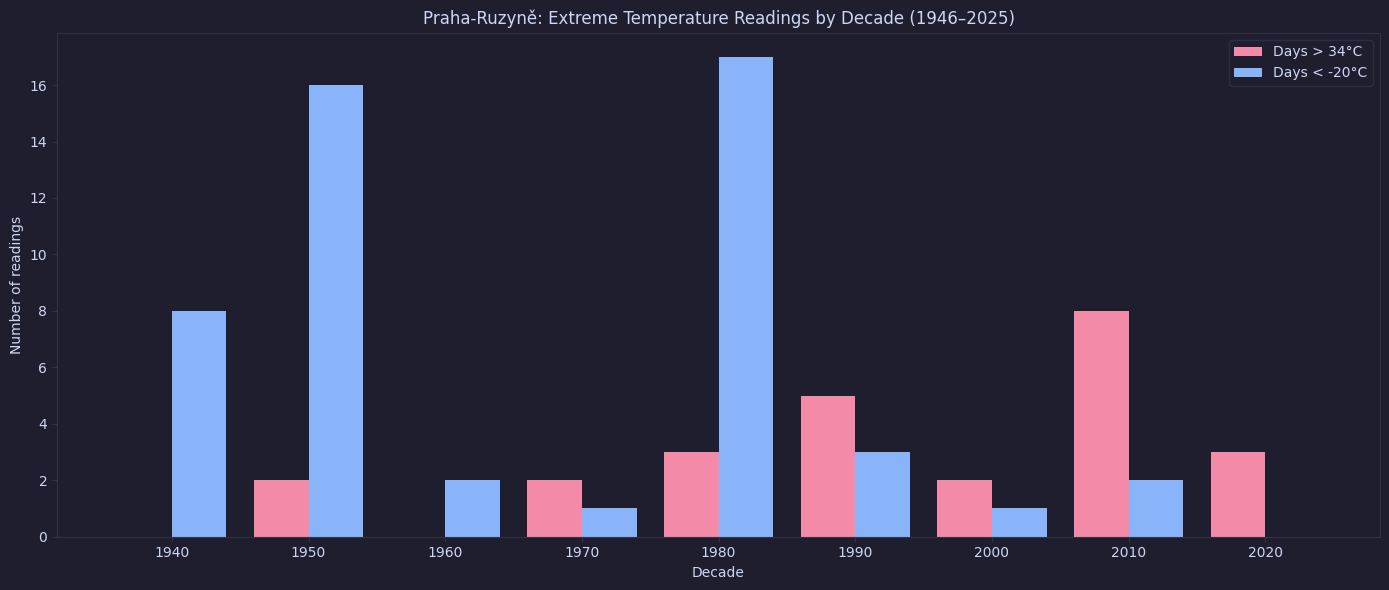

In [188]:
import matplotlib.pyplot as plt
import catppuccin

plt.style.use("mocha")

df["year"] = pd.to_datetime(df["DT"]).dt.year
df["decade"] = (df["year"] // 10) * 10

hot_days = df[df["VALUE"] > 34].groupby("decade").size()
cold_days = df[df["VALUE"] < -20].groupby("decade").size()

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(hot_days.index.union(cold_days.index)))
decades = sorted(hot_days.index.union(cold_days.index))

ax.bar([i - 0.2 for i in x], [hot_days.get(d, 0) for d in decades], width=0.4, label="Days > 34°C", color="#f38ba8")
ax.bar([i + 0.2 for i in x], [cold_days.get(d, 0) for d in decades], width=0.4, label="Days < -20°C", color="#89b4fa")

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_xlabel("Decade")
ax.set_ylabel("Number of readings")
ax.set_title("Praha-Ruzyně: Extreme Temperature Readings by Decade (1946–2025)")
ax.legend()
fig.tight_layout()
plt.show()